In [13]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

## Step 1 - EDA

In [2]:
housing = fetch_california_housing()

In [3]:
housing.data.shape, housing.target.shape

((20640, 8), (20640,))

In [4]:
housing["feature_names"]

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [5]:
housing["target"]

array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,))

In [6]:
df = pd.DataFrame(data = housing["data"], columns = housing["feature_names"])
df["target"] = housing["target"]

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,target
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [7]:
df.shape

(20640, 9)

In [8]:
df.dtypes

MedInc        float64
HouseAge      float64
AveRooms      float64
AveBedrms     float64
Population    float64
AveOccup      float64
Latitude      float64
Longitude     float64
target        float64
dtype: object

In [9]:
df.isna().sum()

MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
target        0
dtype: int64

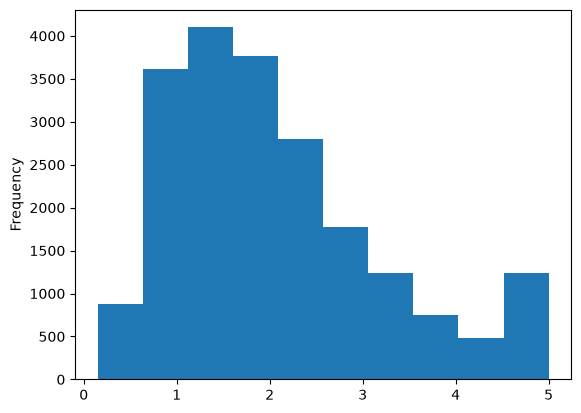

In [10]:
df["target"].plot.hist();

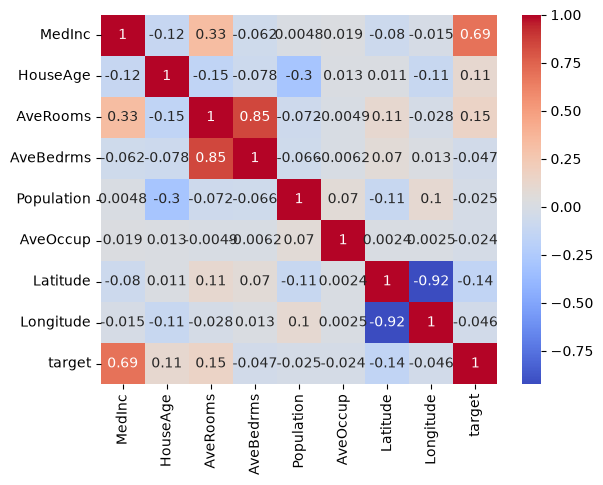

In [11]:
sns.heatmap(df.corr(), annot = True, cmap = 'coolwarm')
plt.show()

## Step 2 — Preprocessing

In [12]:
np.random.seed(42)

X = df.drop("target", axis = 1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2)

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [15]:
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)

In [18]:
X_train_scaled[0]

array([-0.326196  ,  0.34849025, -0.17491646, -0.20836543,  0.76827628,
        0.05137609, -1.3728112 ,  1.27258656])

## Step 3 — Linear Regression from scratch